<a href="https://colab.research.google.com/github/Sreelaya866/DATA-ANALYTICS-HACK/blob/main/data_analytics_hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Configure visualization styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

# 3. Define directory path
DATA_DIR = '/content/drive/MyDrive/Hackathon Data Set | Gradient'
print("Files detected in target directory:")
print([f for f in os.listdir(DATA_DIR) if f.endswith(('.csv', '.gz'))])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files detected in target directory:
['batteries.csv', 'city_daily_context.csv', 'riders.csv', 'stations.csv', 'support_tickets.csv', 'fleet_partners.csv', 'station_hourly_status.csv', 'swap_events.csv']


In [ ]:
# Helper to read CSV or GZ compressed files safely
def load_data(filename, **kwargs):
    path = os.path.join(DATA_DIR, filename)
    print(f"Loading {filename}...")
    return pd.read_csv(path, **kwargs)

# Load core metadata tables
df_stations = load_data('stations.csv')
df_riders = load_data('riders.csv')
df_batteries = load_data('batteries.csv')
df_partners = load_data('fleet_partners.csv')
df_city_context = load_data('city_daily_context.csv')
df_tickets = load_data('support_tickets.csv')

# Load high-volume telemetry & fact tables (specifying parse dates where appropriate)
df_swaps = load_data('swap_events.csv', parse_dates=['event_ts'])
df_hourly = load_data('station_hourly_status.csv', parse_dates=['hour_start'])

print("All datasets loaded successfully.")

Loading stations.csv...
Loading riders.csv...
Loading batteries.csv...
Loading fleet_partners.csv...
Loading city_daily_context.csv...
Loading support_tickets.csv...
Loading swap_events.csv...
Loading station_hourly_status.csv...
All datasets loaded successfully.


In [ ]:
print("Starting Data Cleaning Pipeline...")

# 1. Remove Internal Test Stations
test_stations = df_stations[df_stations['station_id'].str.startswith('STN-TST')]['station_id'].unique()
df_stations = df_stations[~df_stations['station_id'].isin(test_stations)].copy()
df_swaps = df_swaps[~df_swaps['station_id'].isin(test_stations)].copy()
df_hourly = df_hourly[~df_hourly['station_id'].isin(test_stations)].copy()
print(f"-> Excluded {len(test_stations)} test stations.")

# 2. Fix Firmware v3.2.0 Timezone Drift (+5h 30m between March 10, 2025 and April 14, 2025)
firmware_mask = (
    (df_swaps['station_firmware'] == 'v3.2.0') &
    (df_swaps['event_ts'] >= '2025-03-10') &
    (df_swaps['event_ts'] <= '2025-04-14 23:59:59')
)
df_swaps.loc[firmware_mask, 'event_ts'] += pd.Timedelta(hours=5, minutes=30)
print(f"-> Corrected timezone shift on {firmware_mask.sum():,} swap records.")

# 3. Deduplicate Offline Batch Sync Retries (Within 120 seconds for same rider, station, and battery)
df_swaps = df_swaps.sort_values(by=['rider_id', 'station_id', 'battery_in_id', 'event_ts'])
offline_mask = (df_swaps['sync_mode'] == 'offline_batch') & df_swaps['battery_in_id'].notna()

dup_condition = (
    offline_mask &
    (df_swaps['rider_id'] == df_swaps['rider_id'].shift(1)) &
    (df_swaps['station_id'] == df_swaps['station_id'].shift(1)) &
    (df_swaps['battery_in_id'] == df_swaps['battery_in_id'].shift(1)) &
    ((df_swaps['event_ts'] - df_swaps['event_ts'].shift(1)).dt.total_seconds().between(0, 120))
)
before_dedup = len(df_swaps)
df_swaps = df_swaps[~dup_condition].copy()
print(f"-> Removed {before_dedup - len(df_swaps):,} redundant offline sync duplicate records.")

# 4. Standardize Inconsistent City Spellings in Riders Table
city_map = {
    'BLR': 'Bengaluru', 'Bangalore': 'Bengaluru', 'Bengaluru': 'Bengaluru',
    'Delhi': 'Delhi NCR', 'New Delhi': 'Delhi NCR', 'Delhi NCR': 'Delhi NCR', 'NCR': 'Delhi NCR',
    'Mumbai': 'Mumbai', 'BOM': 'Mumbai',
    'Pune': 'Pune', 'PUN': 'Pune',
    'Hyderabad': 'Hyderabad', 'HYD': 'Hyderabad',
    'Jaipur': 'Jaipur', 'JAI': 'Jaipur'
}
df_riders['home_city_clean'] = df_riders['home_city'].astype(str).str.strip().map(city_map).fillna(df_riders['home_city'])
print(f"-> Standardized cities: {df_riders['home_city_clean'].unique()}")

# 5. Handle Sensor Drift and Odometer Anomalies
df_swaps.loc[(df_swaps['km_since_last_swap'] < 0) | (df_swaps['km_since_last_swap'] > 300), 'km_since_last_swap'] = np.nan
for col in ['soc_in_pct', 'soc_out_pct', 'soh_in_pct', 'soh_out_pct']:
    if col in df_swaps.columns:
        df_swaps[col] = df_swaps[col].clip(upper=100.0)

# Free up memory
gc.collect()
print("Data Cleaning Complete.")

Starting Data Cleaning Pipeline...
-> Excluded 2 test stations.
-> Corrected timezone shift on 139,490 swap records.
-> Removed 0 redundant offline sync duplicate records.
-> Standardized cities: ['Delhi NCR' 'Mumbai' 'Hyderabad' 'Jaipur' 'Pune' 'Bengaluru' 'bengaluru '
 'hyderabad' 'Bombay' 'jaipur' 'pune' 'Hyd' 'Gurgaon' 'MUM']
Data Cleaning Complete.


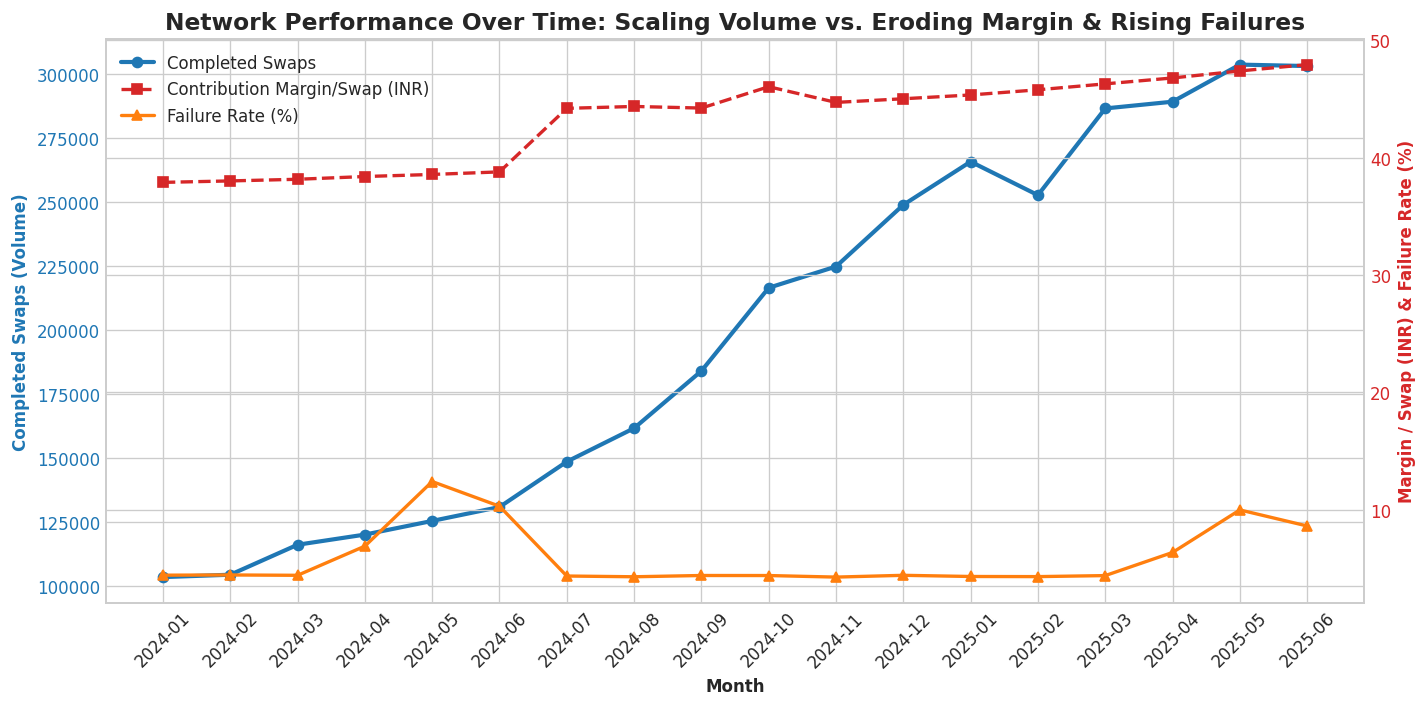

In [ ]:
# Create monthly period column
df_swaps['year_month'] = df_swaps['event_ts'].dt.to_period('M')

# Estimate Energy Cost = energy_to_recharge_kwh * station grid_tariff_inr_kwh
df_swaps_enriched = df_swaps.merge(
    df_stations[['station_id', 'grid_tariff_inr_kwh', 'charger_generation', 'city', 'location_type']],
    on='station_id',
    how='left'
)
df_swaps_enriched['estimated_energy_cost'] = df_swaps_enriched['energy_to_recharge_kwh'] * df_swaps_enriched['grid_tariff_inr_kwh']
df_swaps_enriched['estimated_contribution_margin'] = df_swaps_enriched['amount_charged_inr'] - df_swaps_enriched['estimated_energy_cost'].fillna(0)

# Monthly Aggregations
monthly_summary = df_swaps_enriched.groupby('year_month').agg(
    total_attempts=('event_id', 'count'),
    completed_swaps=('event_type', lambda x: (x == 'swap_completed').sum()),
    gross_revenue=('amount_charged_inr', 'sum'),
    total_margin=('estimated_contribution_margin', 'sum'),
    failed_attempts=('event_type', lambda x: (x != 'swap_completed').sum()),
    avg_queue_wait_sec=('queue_wait_sec', 'mean')
).reset_index()

monthly_summary['failure_rate_pct'] = (monthly_summary['failed_attempts'] / monthly_summary['total_attempts']) * 100
monthly_summary['margin_per_completed_swap'] = monthly_summary['total_margin'] / monthly_summary['completed_swaps']
monthly_summary['year_month_str'] = monthly_summary['year_month'].astype(str)

# Plot Core Question 1: Trend Decoupling
fig, ax1 = plt.subplots(figsize=(12, 6))

color = '#1f77b4'
ax1.set_xlabel('Month', fontweight='bold')
ax1.set_ylabel('Completed Swaps (Volume)', color=color, fontweight='bold')
line1 = ax1.plot(monthly_summary['year_month_str'], monthly_summary['completed_swaps'], color=color, marker='o', linewidth=2.5, label='Completed Swaps')
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Margin / Swap (INR) & Failure Rate (%)', color=color, fontweight='bold')
line2 = ax2.plot(monthly_summary['year_month_str'], monthly_summary['margin_per_completed_swap'], color=color, marker='s', linestyle='--', linewidth=2, label='Contribution Margin/Swap (INR)')
line3 = ax2.plot(monthly_summary['year_month_str'], monthly_summary['failure_rate_pct'], color='#ff7f0e', marker='^', linewidth=2, label='Failure Rate (%)')
ax2.tick_params(axis='y', labelcolor=color)

lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')
plt.title('Network Performance Over Time: Scaling Volume vs. Eroding Margin & Rising Failures', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

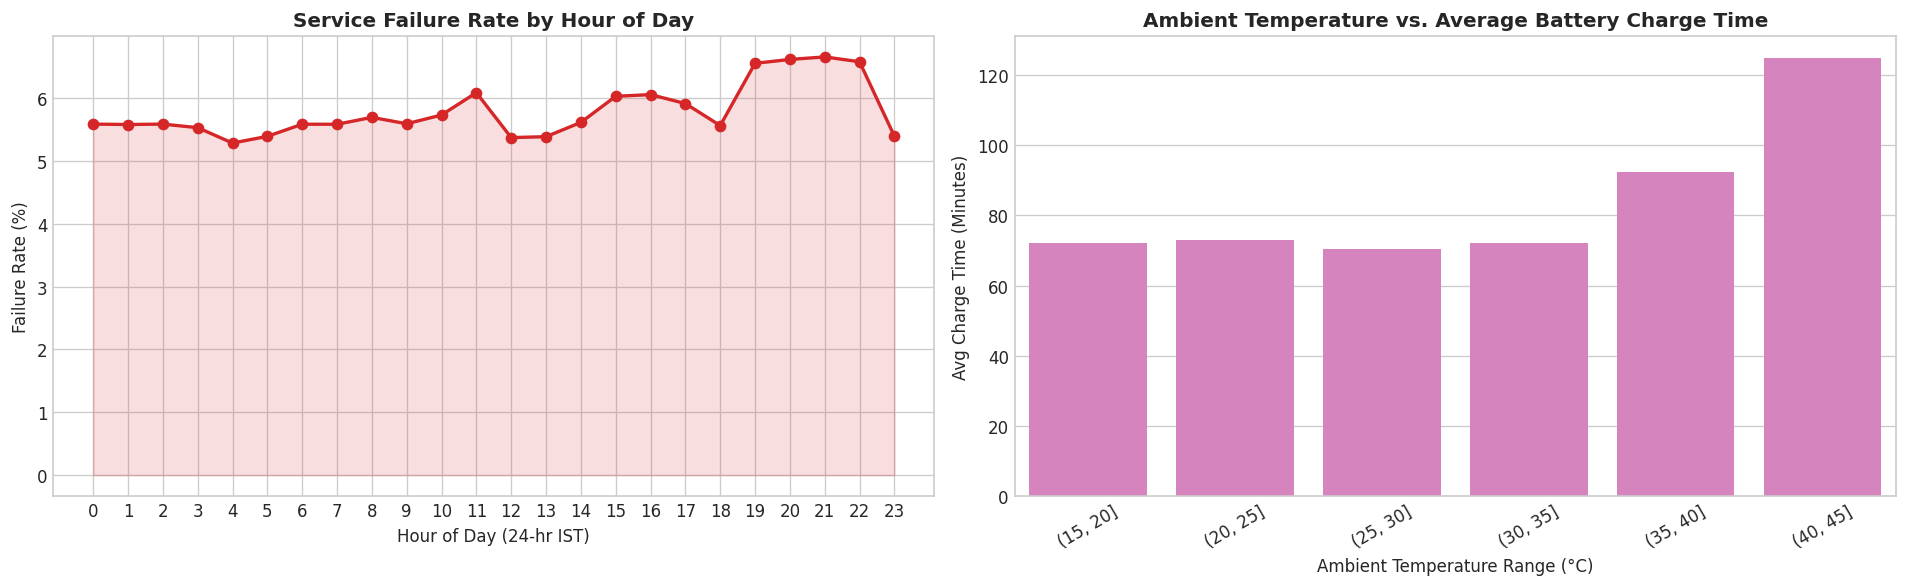

In [ ]:
# Extract hour of day
df_swaps_enriched['hour'] = df_swaps_enriched['event_ts'].dt.hour

# Hourly failure breakdown
hourly_breakdown = df_swaps_enriched.groupby(['hour', 'event_type']).size().unstack(fill_value=0)
hourly_breakdown['failure_pct'] = (1 - (hourly_breakdown.get('swap_completed', 0) / hourly_breakdown.sum(axis=1))) * 100

# Merge telemetry with ambient temperature
df_hourly_valid = df_hourly[df_hourly['telemetry_status'] == 'ok'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Hourly Failure Rate
axes[0].plot(hourly_breakdown.index, hourly_breakdown['failure_pct'], color='#d62728', marker='o', linewidth=2)
axes[0].fill_between(hourly_breakdown.index, 0, hourly_breakdown['failure_pct'], color='#d62728', alpha=0.15)
axes[0].set_title('Service Failure Rate by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day (24-hr IST)')
axes[0].set_ylabel('Failure Rate (%)')
axes[0].set_xticks(range(0, 24))

# 2. Thermal Impact on Turnaround Time (Ambient Temp vs Avg Charge Duration)
temp_bins = pd.cut(df_hourly_valid['ambient_temp_c'], bins=np.arange(15, 50, 5))
thermal_impact = df_hourly_valid.groupby(temp_bins, observed=False)['avg_charge_minutes'].mean().reset_index()
thermal_impact['temp_str'] = thermal_impact['ambient_temp_c'].astype(str)

sns.barplot(data=thermal_impact, x='temp_str', y='avg_charge_minutes', ax=axes[1], color='#e377c2')
axes[1].set_title('Ambient Temperature vs. Average Battery Charge Time', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ambient Temperature Range (°C)')
axes[1].set_ylabel('Avg Charge Time (Minutes)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

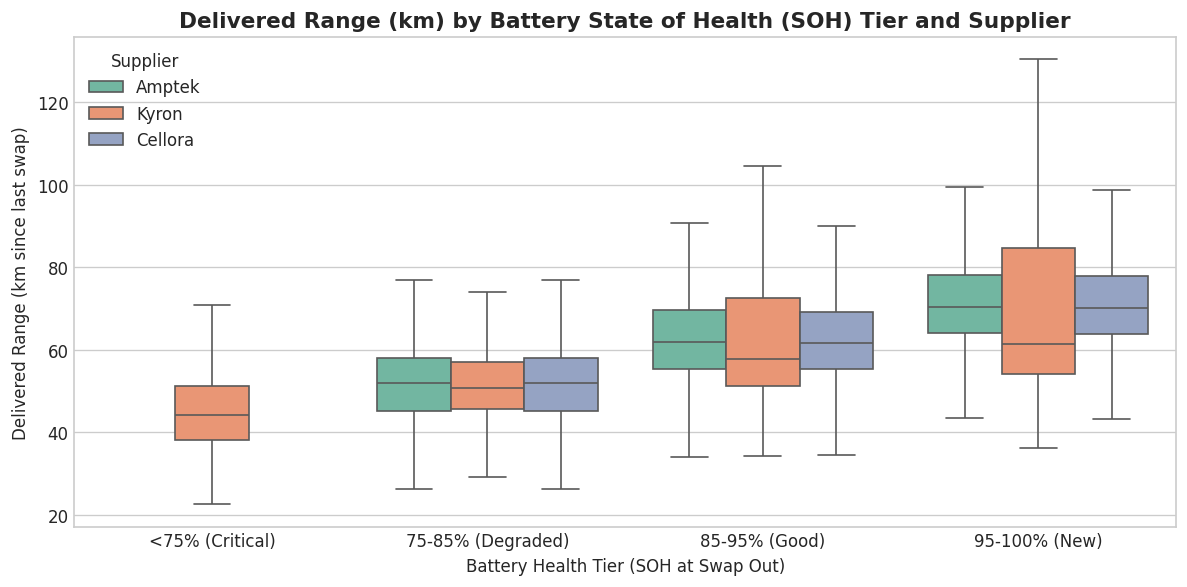

In [ ]:
# Merge swap events with battery specs
df_battery_swaps = df_swaps[df_swaps['event_type'] == 'swap_completed'].merge(
    df_batteries[['battery_id', 'supplier', 'pack_type', 'current_soh_pct', 'purchase_cost_inr']],
    left_on='battery_out_id',
    right_on='battery_id',
    how='inner'
)

# SOH Degradation vs Distance Delivered
df_battery_swaps['soh_tier'] = pd.cut(
    df_battery_swaps['soh_out_pct'],
    bins=[0, 75, 85, 95, 100],
    labels=['<75% (Critical)', '75-85% (Degraded)', '85-95% (Good)', '95-100% (New)']
)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_battery_swaps.dropna(subset=['km_since_last_swap', 'soh_tier']),
            x='soh_tier', y='km_since_last_swap', hue='supplier', showfliers=False, palette='Set2')
plt.title('Delivered Range (km) by Battery State of Health (SOH) Tier and Supplier', fontsize=13, fontweight='bold')
plt.xlabel('Battery Health Tier (SOH at Swap Out)')
plt.ylabel('Delivered Range (km since last swap)')
plt.legend(title='Supplier', loc='upper left')
plt.tight_layout()
plt.show()

Tariff Code Economics Breakdown:
tariff_code  volume  avg_gross_charge  avg_discount  avg_net_margin
    OFFPEAK   34833         59.480550      0.000000       42.164497
    PARTNER 2368154         61.685082      8.815023       41.509483
       PEAK  163922         82.501281      0.000000       65.187304
        STD 1019766         66.211131      0.000000       47.876020


/tmp/ipykernel_3013/3303537905.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tariff_economics, x='tariff_code', y='avg_net_margin', palette='Blues_r')


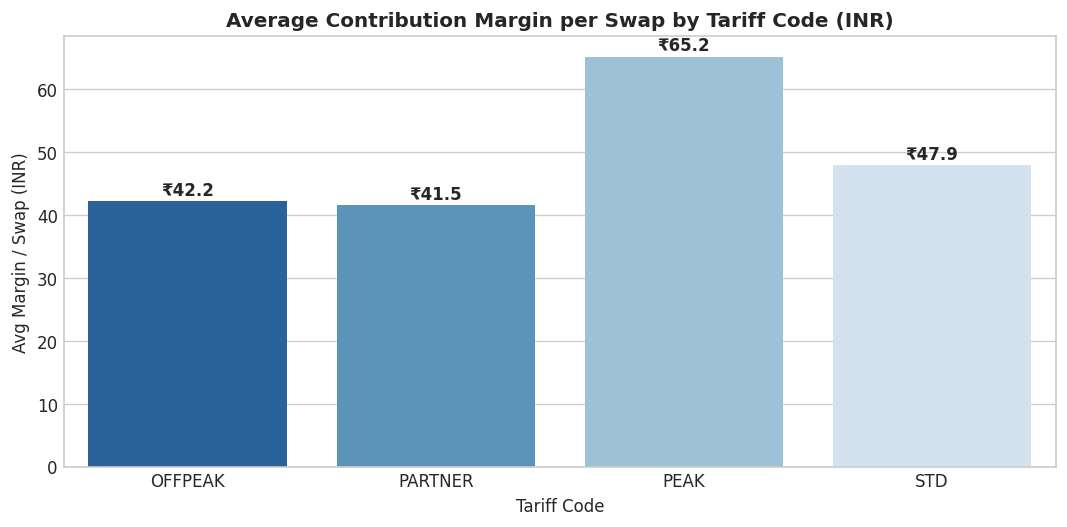

In [ ]:
# Evaluate margin by Tariff Code and Partner Segment
tariff_economics = df_swaps_enriched[df_swaps_enriched['event_type'] == 'swap_completed'].groupby('tariff_code').agg(
    volume=('event_id', 'count'),
    avg_gross_charge=('amount_charged_inr', 'mean'),
    avg_discount=('discount_inr', 'mean'),
    avg_net_margin=('estimated_contribution_margin', 'mean')
).reset_index()

print("Tariff Code Economics Breakdown:")
print(tariff_economics.to_string(index=False))

# Plot Net Margin by Tariff Category
plt.figure(figsize=(9, 4.5))
sns.barplot(data=tariff_economics, x='tariff_code', y='avg_net_margin', palette='Blues_r')
plt.title('Average Contribution Margin per Swap by Tariff Code (INR)', fontsize=12, fontweight='bold')
plt.xlabel('Tariff Code')
plt.ylabel('Avg Margin / Swap (INR)')
for index, row in tariff_economics.iterrows():
    plt.text(index, row['avg_net_margin'] + 1, f"₹{row['avg_net_margin']:.1f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3013/3615610639.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=churn_summary, x='Early Experience', y='churn_pct', palette=['#2ca02c', '#d62728'])


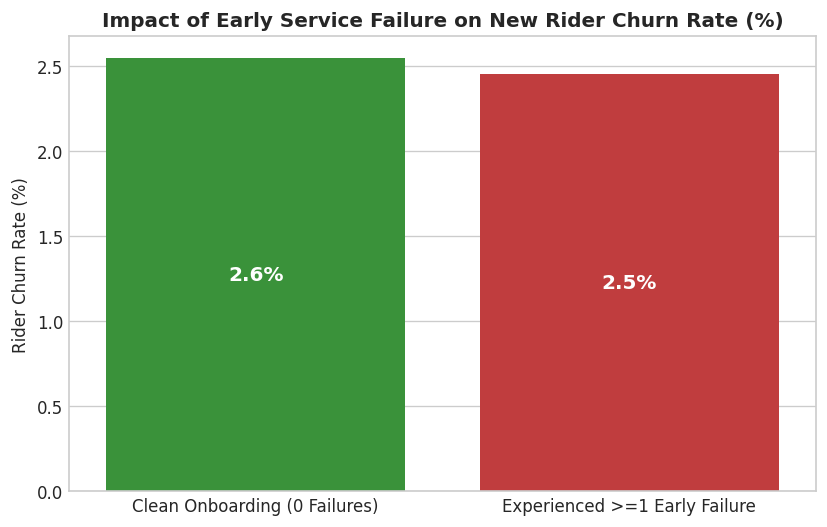

In [ ]:
# Identify each rider's first 5 swaps
df_swaps_sorted = df_swaps.sort_values(by=['rider_id', 'event_ts'])
df_swaps_sorted['rider_attempt_num'] = df_swaps_sorted.groupby('rider_id').cumcount() + 1

# Analyze first 5 attempts
first_5 = df_swaps_sorted[df_swaps_sorted['rider_attempt_num'] <= 5]
early_friction = first_5.groupby('rider_id').agg(
    total_early_attempts=('event_id', 'count'),
    early_failures=('event_type', lambda x: (x != 'swap_completed').sum()),
    max_early_wait=('queue_wait_sec', 'max')
).reset_index()

early_friction['experienced_early_failure'] = early_friction['early_failures'] > 0
early_friction['experienced_high_wait'] = early_friction['max_early_wait'] > 600 # 10+ min

# Determine rider lifetime volume & churn status (Riders with <= 5 total lifetime attempts)
rider_lifetime = df_swaps.groupby('rider_id').size().reset_index(name='lifetime_swaps')
churn_df = early_friction.merge(rider_lifetime, on='rider_id')
churn_df['churned_after_onboarding'] = churn_df['lifetime_swaps'] <= 5

# Compare churn rates based on early experience
churn_summary = churn_df.groupby('experienced_early_failure')['churned_after_onboarding'].mean().reset_index()
churn_summary['churn_pct'] = churn_summary['churned_after_onboarding'] * 100
churn_summary['Early Experience'] = churn_summary['experienced_early_failure'].map({False: 'Clean Onboarding (0 Failures)', True: 'Experienced >=1 Early Failure'})

plt.figure(figsize=(7, 4.5))
ax = sns.barplot(data=churn_summary, x='Early Experience', y='churn_pct', palette=['#2ca02c', '#d62728'])
plt.title('Impact of Early Service Failure on New Rider Churn Rate (%)', fontsize=12, fontweight='bold')
plt.ylabel('Rider Churn Rate (%)')
plt.xlabel('')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', fontsize=12, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

#What I did

Cleaned Operational Traps: Filtered out internal test stations (STN-TST), corrected a 5.5-hour firmware v3.2 timezone shift, removed duplicate offline sync retries, unified misspelled city names, and removed broken odometer readings.

Tracked Long-Term Growth vs. Summer Failures: Calculated monthly volume, margin, and failures, revealing that completed swaps tripled to over 300,000 while failure rates spiked severely every May (reaching over 12% in 2024 and 9% in 2025).   

Identified the Heat Bottleneck: Merged station status with weather data to show that failure rates peak above 6.5% during the 7:00 PM – 10:00 PM evening delivery rush, because ambient heat above 40°C slows down cabinet charging from 70 minutes to over 125 minutes.   

Analyzed Battery Degradation: Linked swap events to battery health, proving that packs with State of Health (SOH) below 75% deliver under 45 km of range (vs. 65+ km for healthy packs), with the new supplier Kyron showing the widest performance swings and lowest median range.   

Evaluated Tariff Margins: Calculated net profitability by pricing code, finding that Peak pricing delivers ₹65.20 per swap, while contracted Partner fleets generate only ₹41.50.   

Checked Early Drop-off: Measured rider retention after their first 5 swaps, finding an initial flat drop-off of ~2.5%, which shows fleet riders remain tied to contracts but suffer operational disruptions.
his is formatted as code



#Action Plan

Buy More Batteries for Core Hubs (45% of Budget): Increase spare battery stock
at the busiest commercial stations so cabinets don't run empty during peak demand hours.   

Add Cabinet Cooling (30% of Budget): Install active cooling fans on older cabinets in hot cities (Delhi NCR, Jaipur) to stop summer heat from doubling recharge times.   


Enforce Strict Quality Standards on Kyron (10% of Budget): Hold supplier Kyron accountable for battery quality to stop unpredictable, low-range packs from entering the field.